# Goal

The goal of this tutorial notebook is to learn how to use flexAE for classification on the well-established [Wisconsin Breast Cancer dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html). This tutorial is very similar to tutorial #1, but applied to a classification task with more features and more entries. I'm also showing a few more features of flexAE.

Note that I assume that you are already familiar with autoencoders, MLP classifiers, and training models in PyTorch. If not, there are a ton of other amazing resources out there to help you get familiar with that. I'm also assuming you're familiar with the idea of flexAE, as presented in Géron et al. (2026). The point of this notebook is to show you how to specifically use flexAE.

# Imports

In [1]:
# General imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import warnings

# Sklearn imports
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.datasets import load_iris, load_breast_cancer

# Pytorch imports
import torch
from torch import optim
from torch.utils.data import TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load flexAE
import sys
sys.path.append("..") #Point this to where the flexAE.py file is located
from flexAE import *

# Code

### Part 1: Loading the data

Let's load the Wisconsin Breast Cancer dataset and inspect it. This dataset should have 30 features, 569 samples, and two classes.

In [2]:
bc_dataset = load_breast_cancer(as_frame=True)

data = bc_dataset['data']
Y = bc_dataset['target']

In [3]:
data

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


Let's standardize the features and load them into tensors.

In [4]:
# Input
X = data.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #Transform
X_tensor = torch.tensor(X_scaled, dtype=torch.float32) # Convert to PyTorch Tensors
Y_tensor = torch.tensor(Y, dtype=torch.long)
feature_names = data.columns

# Create the Dataset
tensor_dataset = TensorDataset(X_tensor,  Y_tensor)

# Divide into train and test
test_split = 0.2
train_dataset, test_dataset = split_tensordataset(tensor_dataset, train_fraction=0.8)

### Part 2: Training flexAE

Here, we first configure the training parameters, the optimizer, and then initialize the flexAE model with a specific architecture. I'm creating a slightly larger model, compared to tutorial #1, to accommodate the larger number of features. I'm also adding a scheduler than adjusts the learning rate during training, and also specifying a gamma parameter. This parameter decides the relative weight in the loss function between the classification loss and the reconstruction loss (see Géron et al. 2026 for more details). A higher gamma will place more importance on the classification.

Finally, note that I also added `include_variational = True` in the model initialization. This will made the autoencoder a variational autoencoder. By default this is turned off. We have a few more options in flexAE, such as: 

- `include_error_head`: This will add a separate input head to add feature uncertainties. This is turned off by default.
- `include_scatter`: This will add a separate decoder scatter component. This is turned off by default.
- `include_classifier`: This will add a classifier component that directly classified on the latent space. This is turned on by default, and we are using it in this tutorial. However, you can explicitly disable it, if you only care about reconstruction.


In [5]:
# Config training parameters
batch_size = 128
epochs = 2_000
learning_rate = 1e-4
validation_split = 0.1
gamma = 5

In [6]:
# Initialize model with architecture
model = flexAE(
    input_dim = X_scaled.shape[1],
    hidden_dim = [16,12,8],
    latent_dim = 4,
    classifier_dim = [8,8,8],
    include_variational = True
).to(device)

In [7]:
# Initialize optimizer and scheduler
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=epochs//10, factor=0.5)

In [8]:
# Train
model.train_model(train_dataset, epochs = epochs, learning_rate = learning_rate, batch_size = batch_size, gamma = gamma,
                  validation_split = validation_split, optimizer = optimizer, scheduler = scheduler)

100%|██████████████████████████████████████████████████| 2000/2000 [00:20<00:00, 97.97it/s]


### Part 3: Inspect model performance

We will now inspect how the model performs. There are a lot of methods you can use associated with flexAE to help with this process.

Let's inspect the loss curve. In this case, there are three different losses that are added together into the total loss: the reconstruction loss, the BCE classification loss, and the KLD loss associated with the variational part of the autoencoder. 

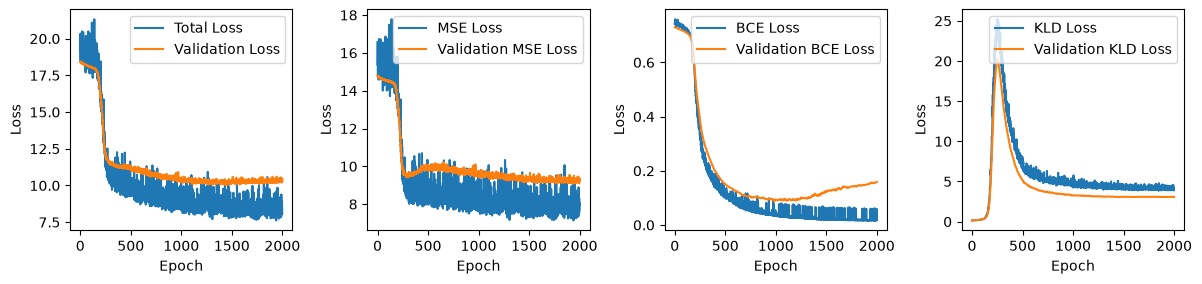

In [9]:
plt.figure(figsize = (12,3))

plt.subplot(1,4,1)
model.plot_loss_per_epoch(losses = ['total','validation'], yscale = 'linear', ax = plt.gca())

plt.subplot(1,4,2)
model.plot_loss_per_epoch(losses = ['mse','val_mse'], yscale = 'linear', ax = plt.gca())

plt.subplot(1,4,3)
model.plot_loss_per_epoch(losses = ['bce','val_bce'], yscale = 'linear', ax = plt.gca())

plt.subplot(1,4,4)
model.plot_loss_per_epoch(losses = ['kld','val_kld'], yscale = 'linear', ax = plt.gca())

plt.tight_layout()
plt.show()

Even though the end goal is classification, flexAE also attempts to use its latent space to reconstruct the input features. You can look at the average residuals for each of the input features to get a sense of how good the reconstruction is.

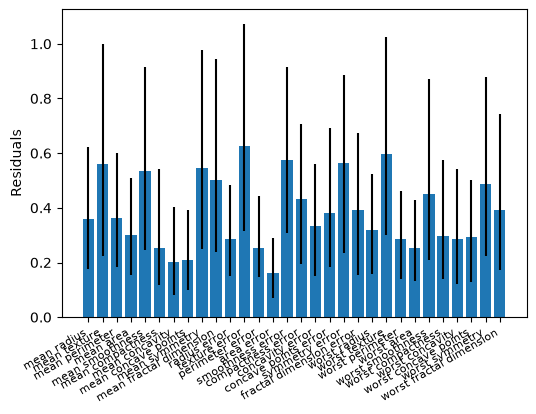

In [10]:
plt.figure(figsize = (6,4))
model.plot_feature_residuals(labels = feature_names, ax = plt.gca())
plt.xticks(rotation = 30, ha = 'right', fontsize = 8)
plt.show()

Instead of looking at the average residuals, you can also directly compare the shape of the input and reconstructed features. It seems like flexAE did an OK-ish job. Some features are reconstructed well, others are not. If you you wanted to improve the reconstruction, you could e.g., increase the number of latent space dimensions, increase the size of the model, or lower the value of gamma. However, keep in mind that we actually mostly care about classification in this case. 

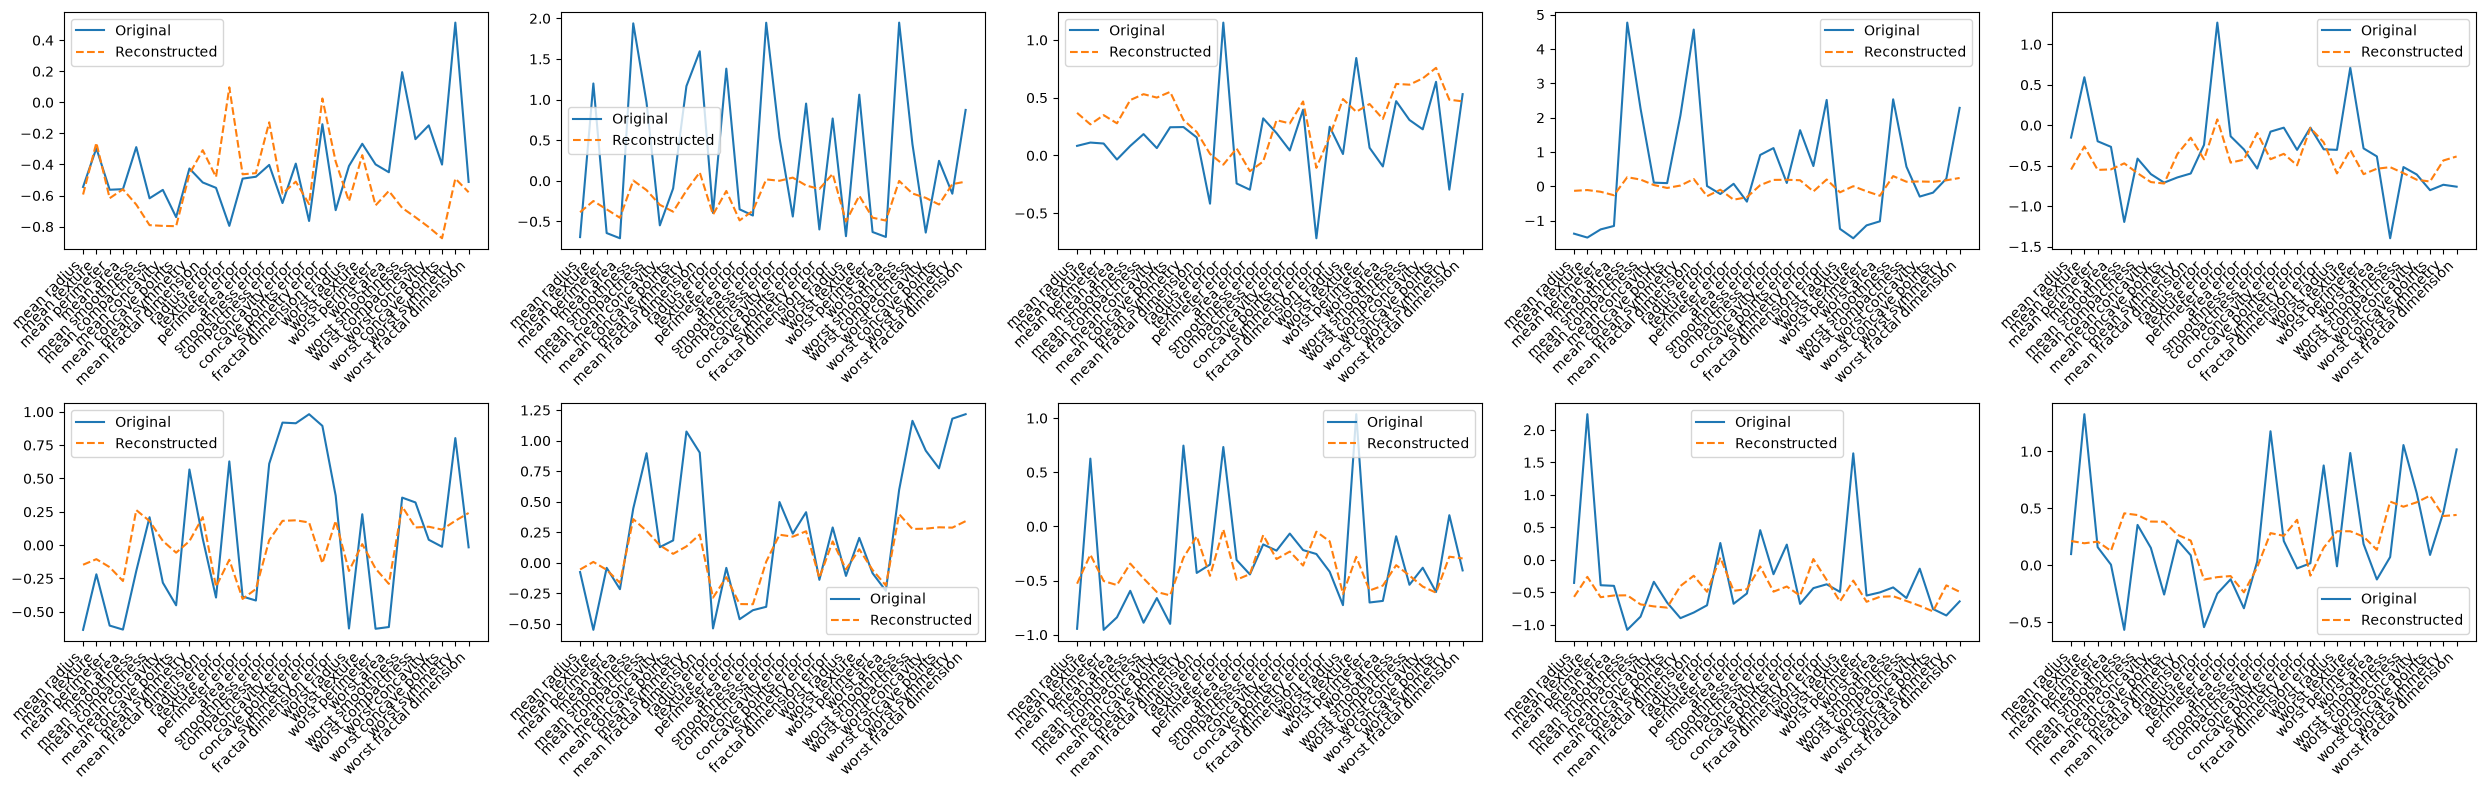

In [11]:
model.compare_reconstructed_features(test_dataset, labels = feature_names, tick_ha = 'right')

While reconstruction is important, in this case, we actually mostly care about the classification accuracy. Let's inspect the latent space to see where the two classes are located. We can do this by running the `encode` method on the tensor with the training data, as shown below. This method returns a dictionary with the encoder output, which in out case only includes the latent space locations (saved in `mu`). We're then using seaborn to plot. It seems like the two classes separate out well, which is promising!

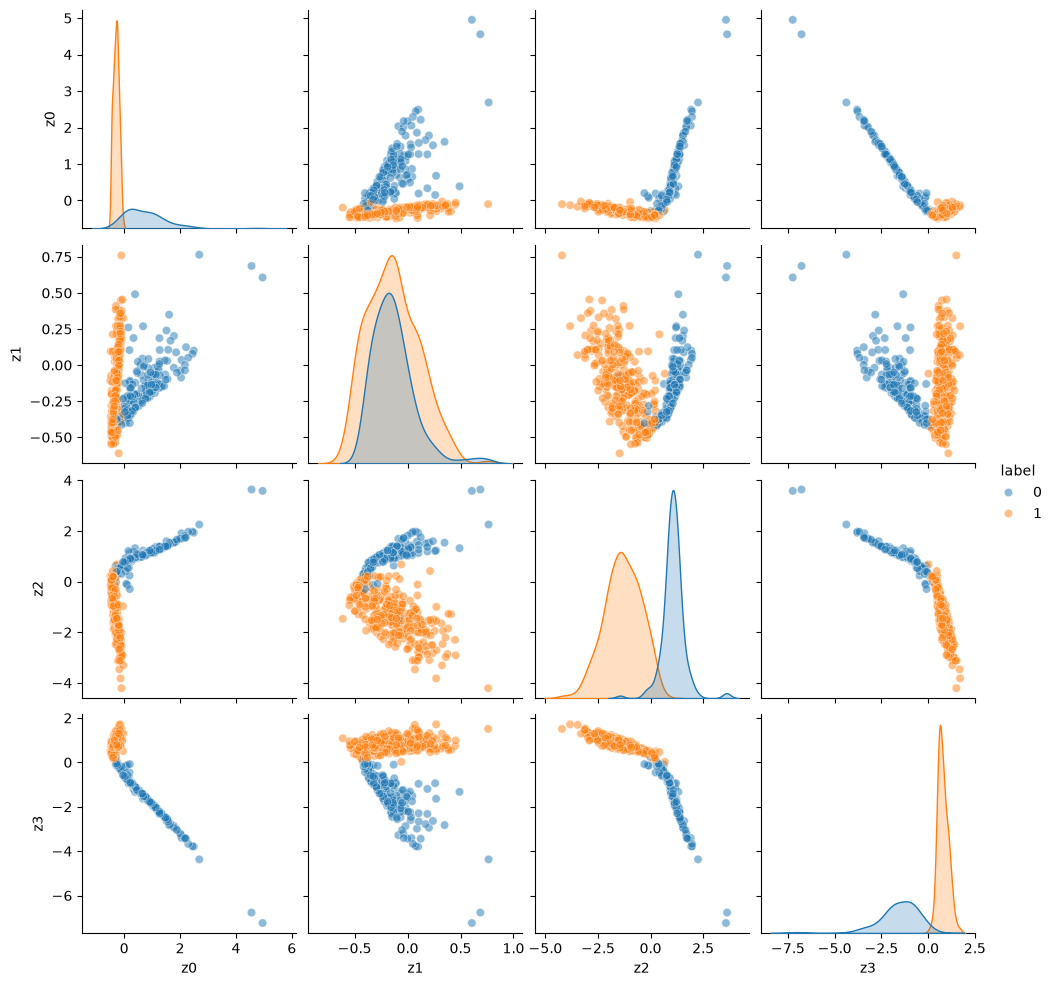

In [12]:
model.eval()
with torch.no_grad():
    data, Y_true = train_dataset.tensors
    Y_true = Y_true.numpy()
    
    encoder_output = model.encode(data)
    mu = encoder_output['mu'].detach().cpu().numpy()


warnings.filterwarnings("ignore", module="seaborn")

df_latent = pd.DataFrame(mu, columns=[f'z{i}' for i in range(mu.shape[1])])
df_latent['label'] = Y_true.astype(str)

sns.pairplot(df_latent, hue='label', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.show()

We will now explicitly look at the classification performance. You can get classification predictions by running `model()` on the tensor with the data. This returns a dictionary that contains the reconstructed features, the latent space locations (mu), and the classification predictions. We care about the latter. It looks like we have a near-perfect classification score for the training set!

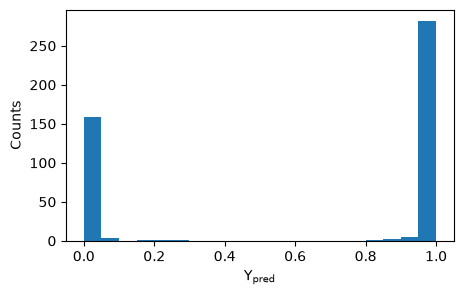

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       166
           1       0.99      1.00      0.99       289

    accuracy                           0.99       455
   macro avg       0.99      0.99      0.99       455
weighted avg       0.99      0.99      0.99       455



In [13]:
model.eval()
with torch.no_grad():
    data, Y_true = train_dataset.tensors
    results = model(data)
    
    Y_pred = results['classification_prediction'].detach().cpu().numpy()
    Y_pred_labels = (np.array(Y_pred) > 0.5).astype(int) #Use 0.5 as a threshold


plt.figure(figsize = (5,3))
plt.hist(Y_pred, bins = 20)
plt.xlabel(r'Y$_{\rm pred}$')
plt.ylabel('Counts')
plt.show()

print(classification_report(Y_true, Y_pred_labels))

Let's look at how well the model classifies the test set. This code is the same as above, but with the test dataset instead. The model still works well!

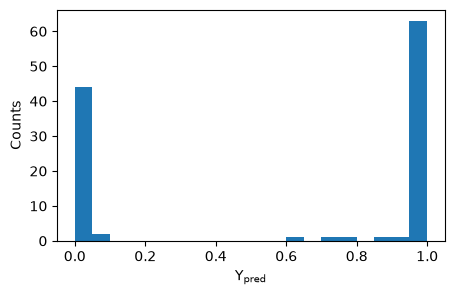

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        46
           1       0.96      0.96      0.96        68

    accuracy                           0.95       114
   macro avg       0.95      0.95      0.95       114
weighted avg       0.95      0.95      0.95       114



In [14]:
model.eval()
with torch.no_grad():
    data, Y_true = test_dataset.tensors
    results = model(data)
    
    Y_pred = results['classification_prediction'].detach().cpu().numpy()
    Y_pred_labels = (np.array(Y_pred) > 0.5).astype(int)


plt.figure(figsize = (5,3))
plt.hist(Y_pred, bins = 20)
plt.xlabel(r'Y$_{\rm pred}$')
plt.ylabel('Counts')
plt.show()

print(classification_report(Y_true, Y_pred_labels))